In [2]:
import torch
import os
import sys
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

project_root = "/home/kkarthik/ARD/sam3"
sys.path.append(project_root)


In [3]:
import json
import numpy as np
import torch
import pycocotools.mask as mask_util 
from scipy.optimize import linear_sum_assignment
import numpy as np

def build_annotation_index(image_id):
    annotations_list = coco_data['annotations']
    annotations_of_image = []
    
    for ann in annotations_list:
        if ann['image_id'] == image_id:
            annotations_of_image.append(ann)
        
    return annotations_of_image

def decode_rle_masks(annotations):
    gt_masks = []
    gt_rles = []
    
    for ann in annotations:
        seg = ann['segmentation']
        gt_rles.append(seg)
        
    gt_masks_np = mask_util.decode(gt_rles) 
    return gt_masks_np

def calculate_iou(mask_a, mask_b):    
    intersection = np.logical_and(mask_a, mask_b).sum()
    union = np.logical_or(mask_a, mask_b).sum()
    
    if union == 0:
        return 0.0
    
    iou = intersection / union
    return iou

In [4]:
import json

# with open('/mnt/harddrive/data/dataset/sam3_format/coco_annotations.json', 'r') as f:
with open('/home/kkarthik/ARD/AIProjects/segment-anything-2/sam2/modeling/backbones/coco_merged2.json', 'r') as f:
    coco_data = json.load(f)

In [5]:
coco_data.keys()

dict_keys(['images', 'annotations', 'categories'])

In [6]:
len(coco_data['images'])

120555

In [7]:
coco_data['images'][0]

{'id': 23180,
 'file_name': '1006524_29_870782_-90_061446.jpg',
 'height': 1024,
 'width': 1024}

In [8]:
len(coco_data['annotations'])

1008953

In [45]:
len(coco_data['images'])

36619

In [44]:
output_file = "/mnt/harddrive/data/dataset/sam3_format/roof_facets_lt_1000pixels.json"

original_count = len(coco_data['annotations'])
filtered_annotations = [
    ann for ann in coco_data['annotations'] 
    if ann.get('area', 0) < 1000
]

active_image_ids = {ann['image_id'] for ann in filtered_annotations}
coco_data['annotations'] = filtered_annotations
coco_data['images'] = [img for img in coco_data['images'] if img['id'] in active_image_ids]

with open(output_file, 'w') as f:
    json.dump(coco_data, f, indent=4)

print(f"Filtered {original_count} annotations down to {len(filtered_annotations)} small facets.")

Filtered 1008953 annotations down to 99558 small facets.


In [42]:
9

9

In [10]:
image_id_filename_map = {}
for image in coco_data['images']:
    image_id = image['id']
    filename = image['file_name']
    image_id_filename_map[image_id]=filename

In [11]:
house_facet_area = {}

for facet in coco_data['annotations']:
    house_id = facet['image_id']
    facet_area = facet['area']
    facet_areas = house_facet_area.get(house_id,[]) + [facet_area]  
    house_facet_area[house_id] = facet_areas

house_num_facets = [] 
for house_id,facets_area in house_facet_area.items():
    house_num_facets.append(len(facets_area))

In [14]:
# house_facet_area

In [12]:
import pandas as pd

data = house_num_facets

df = pd.DataFrame({"value": data})

# Count frequency of each value
freq = df["value"].value_counts().sort_index()

# Percentage of total
percentage = (freq / len(df)) * 100

# Cumulative percentage
cumulative_percentage = percentage.cumsum()

# Combine into one DataFrame
result = pd.DataFrame({
    "count": freq,
    "percentage": percentage,
    "cumulative_percentage": cumulative_percentage
})

result.head(30)

,count,percentage,cumulative_percentage
value,,,
1,622,0.515947,0.515947
2,5396,4.475965,4.991912
3,5265,4.367301,9.359214
4,13411,11.124383,20.483597
5,11888,9.861059,30.344656
6,15015,12.454896,42.799552
7,11976,9.934055,52.733607
8,11530,9.564099,62.297706
9,9025,7.486210,69.783916


Cutoff value (99th percentile): 56166.95999999996
Original count: 1008953 Filtered count: 998863


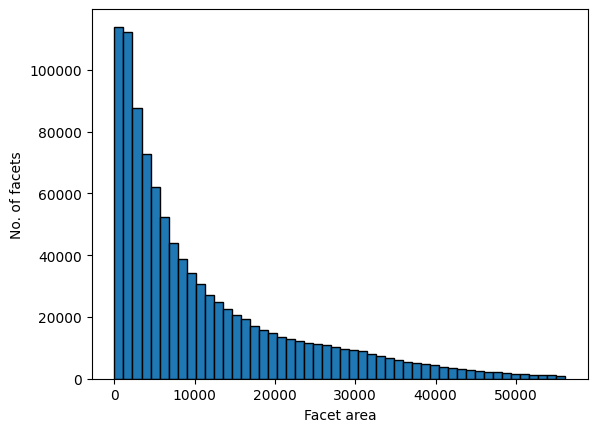

In [13]:
import numpy as np
import matplotlib.pyplot as plt

data_dict = house_facet_area

# Combine all lists
combined = []
for lst in data_dict.values():
    combined.extend(lst)

combined = np.array(combined)

cutoff_percentage = 99
cutoff = np.percentile(combined,cutoff_percentage)

# Filter out values above the cutoff
filtered = combined[combined <= cutoff]

print(f"Cutoff value ({cutoff_percentage}th percentile): {cutoff}")
print("Original count:", len(combined), "Filtered count:", len(filtered))

# Plot histogram
plt.hist(filtered, bins=50, edgecolor='black')
plt.xlabel("Facet area")
plt.ylabel("No. of facets")
plt.show()


In [66]:
combined[:60]

array([ 1,  2,  3,  3,  4,  5,  5,  5,  7,  7,  7,  8,  8,  8,  8,  8,  9,
        9,  9,  9, 10, 11, 12, 13, 13, 14, 14, 14, 15, 15, 15, 15, 15, 15,
       16, 16, 16, 16, 16, 16, 16, 17, 17, 17, 17, 17, 17, 18, 18, 18, 18,
       18, 19, 19, 20, 20, 20, 20, 20, 20])

In [54]:
house_facets_info = {}
area_threshold = 1500
min_area = 500
for house_id,facets_areas in house_facet_area.items():
    facets_under_threshold = sum([area<area_threshold and area>min_area for area in facets_areas])
    total_facets = len(facets_areas)
    house_info = {'num_facets':total_facets, 'num_small_facets':facets_under_threshold}
    house_facets_info[house_id] = house_info

In [12]:
house_facets_info = {}
min_area = 5000

for house_id,facets_areas in house_facet_area.items():
    facets_above_threshold = sum([area>min_area for area in facets_areas])
    total_facets = len(facets_areas)
    house_info = {'num_facets':total_facets, 'num_big_facets':facets_above_threshold}
    house_facets_info[house_id] = house_info

In [38]:
house_facets_info = {}
max_area = 500
min_area = 10

for house_id,facets_areas in house_facet_area.items():
    facets_above_threshold = sum([(area<max_area) and (area>min_area) for area in facets_areas])
    total_facets = len(facets_areas)
    house_info = {'num_facets':total_facets, 'num_small_facets':facets_above_threshold}
    house_facets_info[house_id] = house_info

In [39]:
df = pd.DataFrame(house_facets_info).T
df = df.reset_index()
df = df.rename(columns = {'index':"image_id"})
# df[(df['num_small_facets']>=1) & (df['num_facets']>=6) & (df['num_facets']<25)].sample(10000).sort_values('num_facets',ascending=False)
# df[df['num_big_facets']==df['num_facets']].sample(10000).sort_values('num_facets',ascending=False)
filtered_df = df[df['num_small_facets']!=0]

In [40]:
filtered_df

,image_id,num_facets,num_small_facets
3,76938,24,3
8,7753,7,1
9,103137,9,1
12,23245,47,6
15,34704,11,1
...,...,...,...
120477,29483,16,1
120483,25666,27,2
120485,39961,6,2
120523,96639,15,4


In [20]:
filtered_df.sort_values('num_facets',ascending=False)

,image_id,num_facets,num_small_facets
15354,60305,130,88
46330,108744,94,49
96702,73250,85,10
115745,19390,76,32
98023,8888,76,17
...,...,...,...
94303,28923,3,1
74529,71125,3,1
1305,51644,2,1
9444,88840,2,1


In [30]:
plt.imread('/mnt/harddrive/data/dataset/sam2_format/rgb_resized/'+coco_data['images'][1305]['file_name']).shape

(1024, 1024, 3)

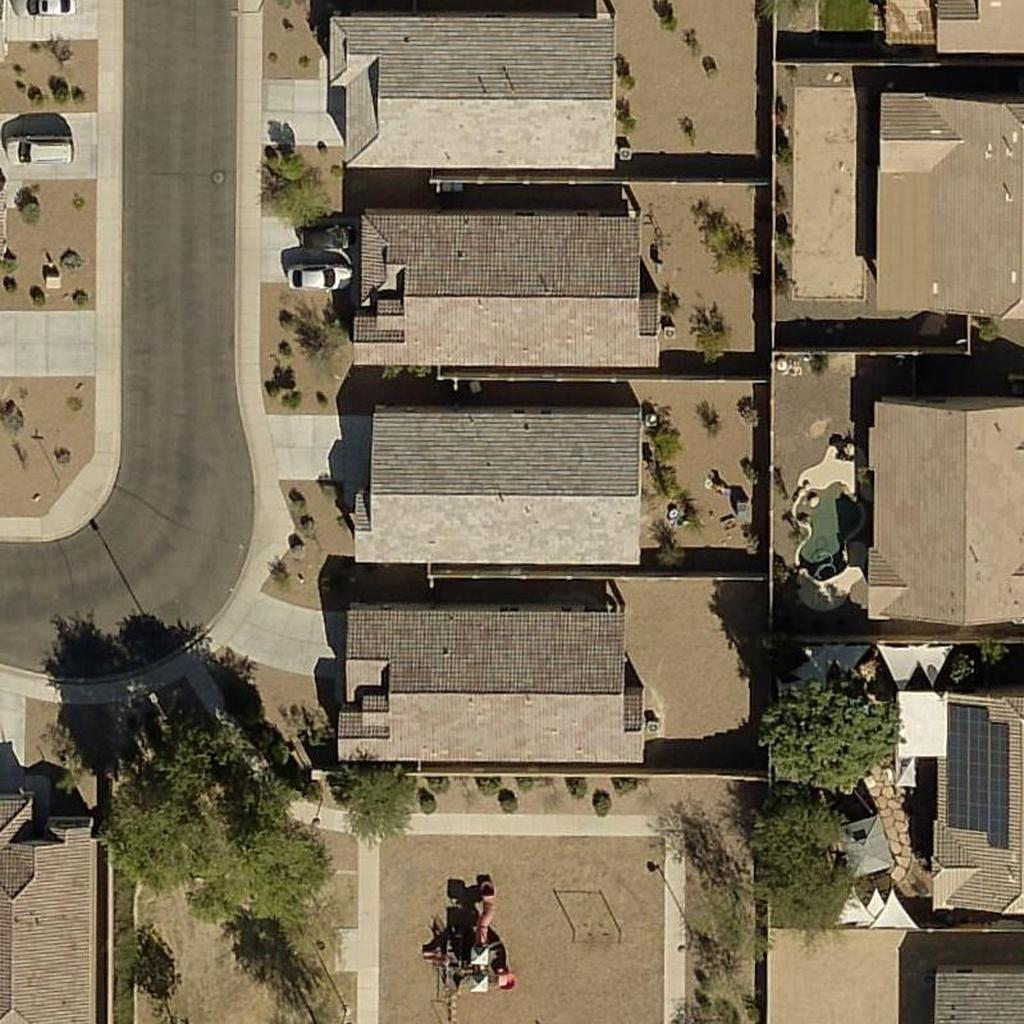

In [36]:
Image.open('/mnt/harddrive/data/dataset/sam2_format/rgb_resized/'+coco_data['images'][94303]['file_name'])

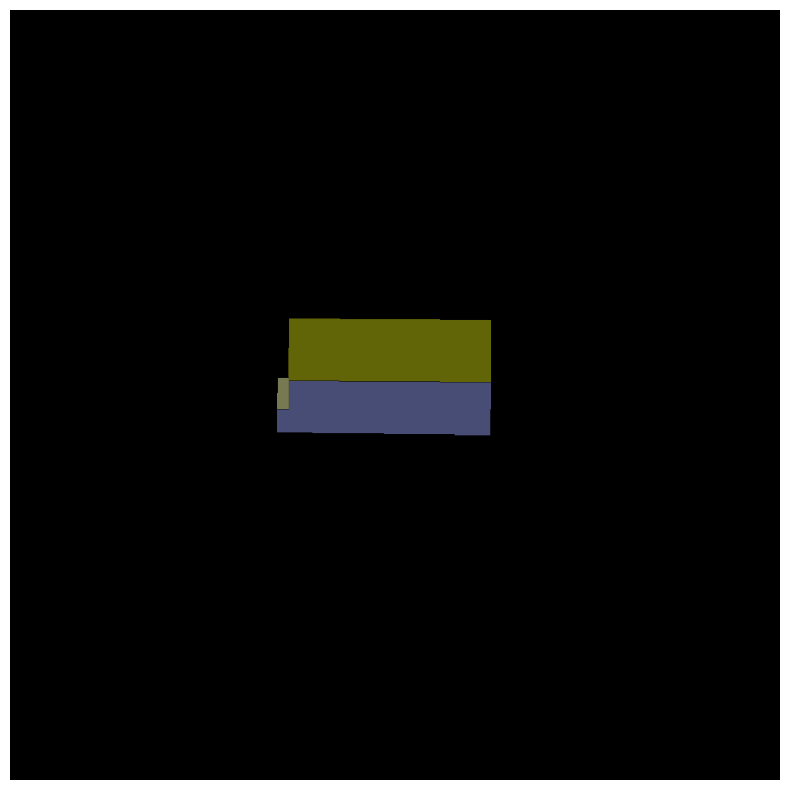

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pycocotools import mask as mask_utils

total_anns = len(coco_data['annotations'])
image_id = 28923
img_annotations = []
for i in range(total_anns):
    if coco_data['annotations'][i]['image_id'] == image_id :
        img_annotations.append(coco_data['annotations'][i])

annotations = img_annotations

fig, ax = plt.subplots(figsize=(10, 10))
# Create a blank black image to draw on
canvas = np.zeros((1024, 1024, 3))
ax.imshow(canvas)

for ann in annotations:
    # 1. Draw the Mask
    rle = ann['segmentation']
    binary_mask = mask_utils.decode(rle)
    
    # Create a colored overlay for the mask
    mask_overlay = np.zeros((1024, 1024, 4)) # RGBA
    color = np.random.rand(3)
    mask_overlay[binary_mask == 1] = [*color, 0.5] # 50% transparency
    ax.imshow(mask_overlay)

    # 2. Draw the Bounding Box (Lines)
    x, y, w, h = ann['bbox']
    rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor=color, facecolor='none')
    # ax.add_patch(rect)

plt.axis('off')
plt.show()

In [22]:
filtered_df['file_name'] = filtered_df['image_id'].apply(lambda x:image_id_filename_map[x])

/tmp/ipykernel_215673/2395622420.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['file_name'] = filtered_df['image_id'].apply(lambda x:image_id_filename_map[x])


In [23]:
len(filtered_df['file_name'].tolist())

4979

In [24]:
filenames = filtered_df['file_name'].tolist()

with open('/mnt/harddrive/data/dataset/sam3_format/sam2/image_list_very_small.txt', 'w') as f:
    for name in filenames:
        f.write(f"{name}\n")  

In [58]:
df.head(1)

,image_id,num_facets,num_small_facets
0,23180,10,0


In [39]:
coco_data['images'][115745]

{'id': 19390,
 'file_name': '2195497_34_119646_-118_012784.jpg',
 'height': 1024,
 'width': 1024}

In [61]:
total_anns = len(coco_data['annotations'])
image_id = 60305
img_annotations = []
for i in range(total_anns):
    if coco_data['annotations'][i]['image_id'] == image_id :
        img_annotations.append(coco_data['annotations'][i])

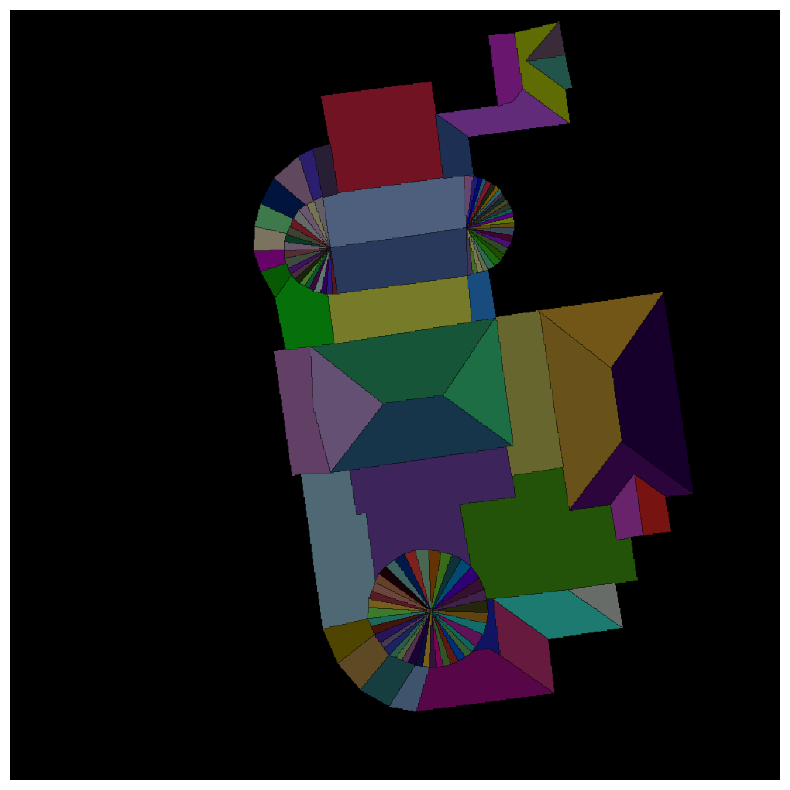

In [62]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pycocotools import mask as mask_utils

# Your provided data
annotations = img_annotations

fig, ax = plt.subplots(figsize=(10, 10))
# Create a blank black image to draw on
canvas = np.zeros((1024, 1024, 3))
ax.imshow(canvas)

for ann in annotations:
    # 1. Draw the Mask
    rle = ann['segmentation']
    binary_mask = mask_utils.decode(rle)
    
    # Create a colored overlay for the mask
    mask_overlay = np.zeros((1024, 1024, 4)) # RGBA
    color = np.random.rand(3)
    mask_overlay[binary_mask == 1] = [*color, 0.5] # 50% transparency
    ax.imshow(mask_overlay)

    # 2. Draw the Bounding Box (Lines)
    x, y, w, h = ann['bbox']
    rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor=color, facecolor='none')
    # ax.add_patch(rect)

plt.axis('off')
plt.show()

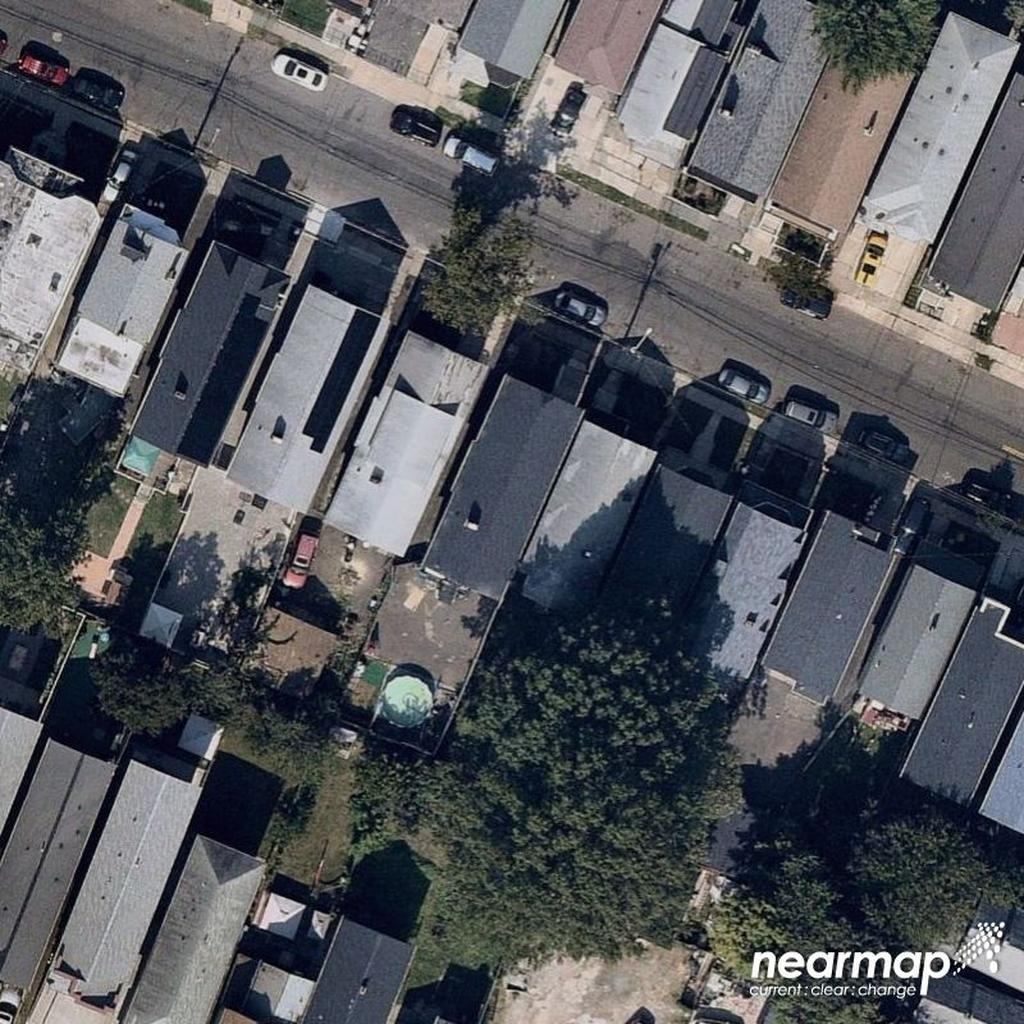

In [41]:
Image.open('/mnt/harddrive/data/dataset/sam2_format/rgb_resized/'+coco_data['images'][7072]['file_name'])

In [48]:
(df[(df['num_small_facets']>=1) & (df['num_facets']>=8)])

,image_id,num_facets,num_small_facets
3,76938,24,7
9,103137,9,2
12,23245,47,26
15,34704,11,3
17,108067,11,6
...,...,...,...
120527,118300,15,4
120537,71351,9,1
120541,252,11,1
120544,110624,9,1


In [60]:
import json
from collections import defaultdict

target_image_ids = set(df[(df['num_small_facets']>=1) & (df['num_facets']>=6) & (df['num_facets']<=25)].sample(10000).sort_values('num_facets',ascending=False).image_id)
target_image_ids = set(df.head(10).image_id)

filtered_images = [
    img for img in coco_data['images'] 
    if img['id'] in target_image_ids
]
kept_image_ids = {img['id'] for img in filtered_images}
filtered_annotations = [
    ann for ann in coco_data['annotations'] 
    if ann['image_id'] in kept_image_ids]

filtered_coco_data = {
    'images': filtered_images,
    'annotations': filtered_annotations,
    'categories': coco_data['categories'] 
}

output_file = '/mnt/harddrive/data/dataset/sam3_format/filtered_coco_10k_sample_min_1_small_facet_area_threshold_100_1250_max_25_facets.json'
output_file = '/mnt/harddrive/data/dataset/sam3_format/sample_10.json'

with open(output_file, 'w') as f:
    json.dump(filtered_coco_data, f, indent=4)
    

In [61]:
df.head(10)

,image_id,num_facets,num_small_facets
0,23180,10,0
1,93793,4,0
2,45556,4,0
3,76938,24,5
4,32373,1,0
5,52391,2,0
6,84781,7,0
7,75509,5,0
8,7753,7,2
9,103137,9,1


In [87]:
df[(df['num_small_facets']==0) & (df['num_facets']>=8)]

,image_id,num_facets,num_small_facets
0,23180,10,0
21,119763,9,0
24,106458,8,0
64,53938,15,0
75,22152,11,0
...,...,...,...
120513,92183,8,0
120514,79302,8,0
120531,97778,13,0
120532,96037,12,0


In [94]:
import json
from collections import defaultdict

target_image_ids = set(df[(df['num_small_facets']==0) & (df['num_facets']>=8)].image_id)

filtered_images = [
    img for img in coco_data['images'] 
    if img['id'] in target_image_ids
]
kept_image_ids = {img['id'] for img in filtered_images}
filtered_annotations = [
    ann for ann in coco_data['annotations'] 
    if ann['image_id'] in kept_image_ids]

filtered_coco_data = {
    'images': filtered_images,
    'annotations': filtered_annotations,
    'categories': coco_data['categories'] 
}

output_file = '/mnt/harddrive/data/dataset/sam3_format/filtered_coco_min_8_facets_0_small_1250_threshold.json'
with open(output_file, 'w') as f:
    json.dump(filtered_coco_data, f, indent=4)
    

In [272]:
len(filtered_coco_data['images'])

23560

In [ ]:
gt_rles = []
for i in range(1,int(len(filtered_coco_data['images'])/100)):
    for ann in filtered_coco_data['annotations'][100*(i-1):100*i]:
        seg = ann['segmentation']
        gt_rles.append(seg)
        gt_masks_np = mask_util.decode(gt_rles) 
    print(100*i, sum(np.sum(gt_masks_np,axis=(0,1))<10))

100 0
200 0
300 0


In [284]:
gt_masks_np.shape

(1024, 1024, 100)

In [288]:
sum(np.sum(gt_masks_np,axis=(0,1))<10)

0

In [31]:
df.shape

(120555, 3)

In [41]:
import json
import pandas as pd
from typing import Dict, Any, Set, List

def filter_and_validate_coco(
    coco_data: Dict[str, Any], 
    df: pd.DataFrame, 
) -> Dict[str, Any]:
    """
    Filters COCO data based on DataFrame criteria and performs validation 
    to remove corrupted annotations (zero-area bounding boxes).

    Args:
        coco_data: The loaded COCO dictionary.
        df: DataFrame containing pre-calculated metrics ('num_facets', 'num_small_facets').
        input_path: Path to the original COCO file (for reference).
        output_path: Path to save the new, clean COCO file.

    Returns:
        The filtered COCO dictionary.
    """
    print(f"--- Starting Validation and Filtering ---")
    print(f"Original Annotations: {len(coco_data['annotations'])}")
    
    # --- 1. Filter Images based on DataFrame Criteria ---
    
    # Calculate the set of Image IDs that meet the complexity thresholds
    target_image_ids = set(
        df['image_id']
    )
    
    # --- 2. Filter Annotations (Including Corruption Check) ---
    valid_annotations: List[Dict[str, Any]] = []
    removed_count = 0
    
    for ann in coco_data['annotations']:
        image_id = ann.get('image_id')
        bbox = ann.get('bbox')
        
        # A. Check if the image ID is in the target set
        if image_id not in target_image_ids:
            continue
        
        # B. Validation Check for Corruption
        # COCO bbox format: [x, y, width, height]
        width = bbox[2]
        height = bbox[3]
        
        # CRITICAL FIX: Remove all annotations where width or height is non-positive.
        if width <= 0 or height <= 0:
            removed_count += 1
            continue
            
        valid_annotations.append(ann)

    # --- 3. Final Assembly ---
    
    # Get the IDs of images that successfully retained at least one valid annotation
    kept_image_ids = {ann['image_id'] for ann in valid_annotations}
    
    # Filter the images list one final time
    filtered_images = [
        img for img in coco_data['images'] 
        if img['id'] in kept_image_ids
    ]
    
    # --- 4. Save and Report ---
    cleaned_coco_data = {
        'images': filtered_images,
        'annotations': valid_annotations,
        'categories': coco_data['categories'] 
    }

        
    print(f"\n--- Validation Summary ---")
    print(f"Total Corrupted/Filtered Annotations Removed: {removed_count}")
    print(f"Total Annotations Remaining: {len(valid_annotations)}")
    # print(f"Clean COCO file saved to: {output_path}")
    
    # return cleaned_coco_data

# --- EXAMPLE USAGE (UPDATE YOUR PATHS AND LOAD YOUR DF/COCO DATA) ---
# NOTE: You must ensure 'df' and 'coco_data' are loaded pandas DataFrame 
# and dictionary objects in your session before running this function.

# INPUT_JSON = '/path/to/original.json' 
# OUTPUT_JSON = '/mnt/harddrive/data/dataset/sam3_format/cleaned_validated_coco.json'
# coco_data = json.load(open(INPUT_JSON, 'r'))
# df = pd.read_csv('path/to/df.csv') 
# 
input_file = '/mnt/harddrive/data/dataset/sam3_format/filtered_coco_min_8_facets_min_1_small_1250_threshold.json'
input_file = '/home/kkarthik/ARD/AIProjects/segment-anything-2/sam2/modeling/backbones/coco_merged2.json'
coco_data = json.load(open(input_file, 'r'))

filter_and_validate_coco(coco_data, df)

--- Starting Validation and Filtering ---
Original Annotations: 1008953

--- Validation Summary ---
Total Corrupted/Filtered Annotations Removed: 0
Total Annotations Remaining: 1008953


In [43]:
coco_data['annotations'][0]

{'id': 1,
 'image_id': 23180,
 'category_id': 1,
 'bbox': [397, 454, 60, 66],
 'area': 1737,
 'iscrowd': 0,
 'segmentation': {'size': [1024, 1024],
  'counts': 'g^]<3mo03L5L004L5K4J6L004L2M1000O100O02O005K4K6K003MN2N0O300N2N2N20ON3O1M2O200M3O1N1N300O1M10200M3O1M2O200M3O0N300N2N2N0O300Nlafa0'}}

In [81]:
(coco_data['images'])[0]

{'id': 76938,
 'file_name': '1025980_26_023359_-80_331516.jpg',
 'height': 1024,
 'width': 1024}

In [85]:
for idx,image_data in enumerate(coco_data['images']):
    if image_data['file_name'] not in os.listdir('/mnt/harddrive/data/dataset/sam2_format/rgb_resized/'):
        print(image_data)
    if idx%1000 == 0:
        print(idx)

0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
20000
21000
22000
23000
24000
25000
26000
27000
28000
29000
30000
31000
32000
33000


In [21]:
# Image.open('/mnt/harddrive/data/dataset/sam2_format/rgb_resized/'+coco_data['images'][17]['file_name'])

In [104]:
df[(df['num_facets']<4) & (df['num_small_facets']!=0)]

,image_id,num_facets,num_small_facets
350,101210,3,1
401,62537,3,1
579,81350,3,1
700,32819,3,1
877,54499,3,1
...,...,...,...
118412,112507,3,1
118997,5485,3,1
119018,105401,3,1
119784,20274,3,1


In [90]:
coco_data['images'][1]

{'id': 93793,
 'file_name': '1011525_30_403343_-90_157723.jpg',
 'height': 1024,
 'width': 1024}

In [44]:
import json
import pandas as pd
from typing import Dict, Any, Set, List

def polygon_area(seg: List[float]) -> float:
    """Compute area of a polygon using the shoelace formula."""
    if len(seg) < 6:
        return 0.0

    xs = seg[0::2]
    ys = seg[1::2]
    
    area = 0.0
    for i in range(len(xs)):
        j = (i + 1) % len(xs)
        area += xs[i] * ys[j] - xs[j] * ys[i]
        
    return abs(area) / 2.0


def is_valid_segmentation(segmentation: Any) -> bool:
    """
    Validate COCO polygon-based segmentation.
    Returns True only if segmentation is non-empty and has positive area.
    """
    if not segmentation:
        return False
    
    # segmentation is a list of polygons
    for poly in segmentation:
        if len(poly) < 6:
            return False
        
        if polygon_area(poly) <= 0:
            return False
    
    return True


def filter_and_validate_coco_seg(
    coco_data: Dict[str, Any],
    df: pd.DataFrame,
) -> Dict[str, Any]:
    """
    Filters COCO using image_id list from df AND validates segmentation instead of bbox.
    """
    print(f"--- Starting Validation and Filtering (Segmentation-Based) ---")
    print(f"Original Annotations: {len(coco_data['annotations'])}")

    # 1. Allowed images
    target_image_ids = set(df['image_id'])

    valid_annotations = []
    removed_count = 0

    for ann in coco_data["annotations"]:
        image_id = ann.get("image_id")
        segmentation = ann.get("segmentation")

        # A. Image filter
        if image_id not in target_image_ids:
            continue
        
        # B. Segmentation validation
        if not is_valid_segmentation(segmentation):
            removed_count += 1
            continue
        
        valid_annotations.append(ann)

    # 3. Keep only images with surviving annotations
    kept_image_ids = {ann["image_id"] for ann in valid_annotations}

    filtered_images = [
        img for img in coco_data["images"]
        if img["id"] in kept_image_ids
    ]

    cleaned_coco_data = {
        "images": filtered_images,
        "annotations": valid_annotations,
        "categories": coco_data["categories"]
    }

    print("\n--- Validation Summary ---")
    print(f"Total Invalid/Removed Annotations: {removed_count}")
    print(f"Total Remaining Annotations: {len(valid_annotations)}")

    return cleaned_coco_data


In [45]:
coco_data = json.load(open(input_file, "r"))

cleaned = filter_and_validate_coco_seg(coco_data, df)


--- Starting Validation and Filtering (Segmentation-Based) ---
Original Annotations: 1008953

--- Validation Summary ---
Total Invalid/Removed Annotations: 1008953
Total Remaining Annotations: 0
